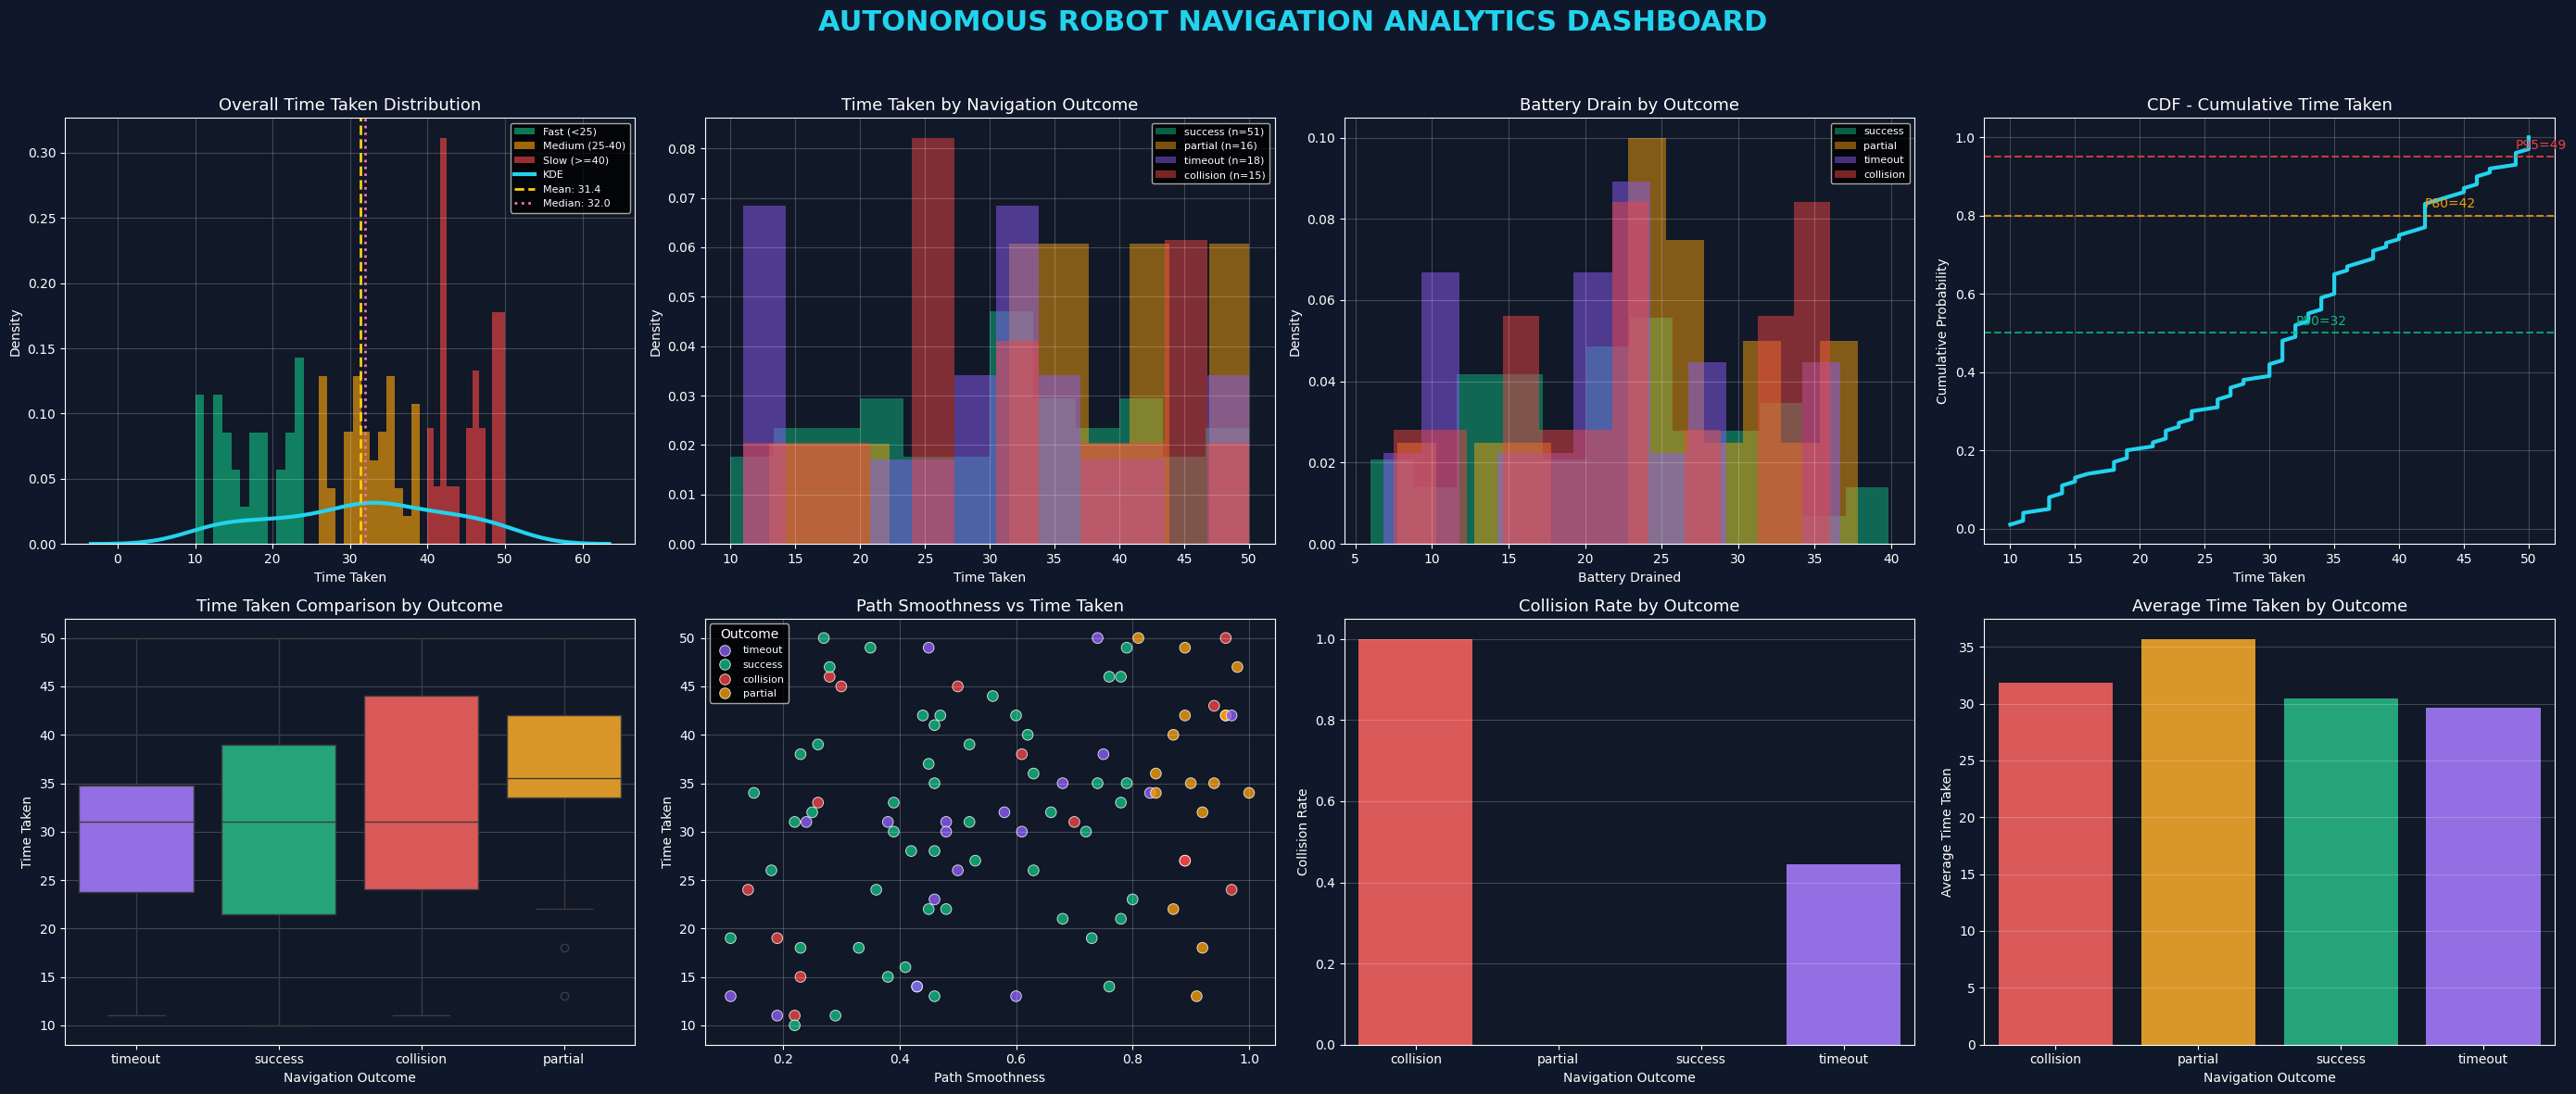

In [ ]:
# ==========================
# AUTONOMOUS ROBOT NAVIGATION ANALYTICS DASHBOARD
# 1 RUN = 8 CHARTS
# ==========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================
# 1. LOAD DATA
# ==========================

df = pd.read_csv("autonomous_navigation_dataset.csv")

# ==========================
# 2. PREPARE RUN-LEVEL DATA
# ==========================

run_df = df.groupby("run_id").agg({
    "time_taken": "first",
    "target": "first",
    "collision_flag": "max",
    "path_smoothness": "first",
    "battery_level": ["first", "last"]
}).reset_index()

run_df.columns = [
    "run_id",
    "time_taken",
    "target",
    "collision_flag",
    "path_smoothness",
    "battery_start",
    "battery_end"
]

run_df["battery_drained"] = run_df["battery_start"] - run_df["battery_end"]

# ==========================
# 3. DARK STYLE SETUP
# ==========================

plt.style.use("dark_background")

colors = {
    "success": "#10b981",
    "partial": "#f59e0b",
    "timeout": "#8b5cf6",
    "collision": "#ef4444"
}

fig, axes = plt.subplots(2, 4, figsize=(28, 12))
fig.patch.set_facecolor("#0f172a")

for ax in axes.flatten():
    ax.set_facecolor("#111827")
    ax.grid(True, alpha=0.2)

# ==========================
# CHART 1 - OVERALL TIME TAKEN DISTRIBUTION
# ==========================

ax = axes[0, 0]

time_data = run_df["time_taken"]

ax.hist(time_data[time_data < 25], bins=12, alpha=0.65,
        color="#10b981", density=True, label="Fast (<25)")

ax.hist(time_data[(time_data >= 25) & (time_data < 40)], bins=12,
        alpha=0.65, color="#f59e0b", density=True, label="Medium (25-40)")

ax.hist(time_data[time_data >= 40], bins=12, alpha=0.65,
        color="#ef4444", density=True, label="Slow (>=40)")

sns.kdeplot(time_data, ax=ax, color="#22d3ee", linewidth=3, label="KDE")

mean_time = time_data.mean()
median_time = time_data.median()

ax.axvline(mean_time, color="#facc15", linestyle="--",
           linewidth=2, label=f"Mean: {mean_time:.1f}")

ax.axvline(median_time, color="#f472b6", linestyle=":",
           linewidth=2, label=f"Median: {median_time:.1f}")

ax.set_title("Overall Time Taken Distribution", fontsize=13)
ax.set_xlabel("Time Taken")
ax.set_ylabel("Density")
ax.legend(fontsize=8)

# ==========================
# CHART 2 - TIME TAKEN BY OUTCOME
# ==========================

ax = axes[0, 1]

for target, color in colors.items():
    subset = run_df[run_df["target"] == target]
    ax.hist(subset["time_taken"], bins=12, alpha=0.5,
            density=True, color=color, label=f"{target} (n={len(subset)})")

ax.set_title("Time Taken by Navigation Outcome", fontsize=13)
ax.set_xlabel("Time Taken")
ax.set_ylabel("Density")
ax.legend(fontsize=8)

# ==========================
# CHART 3 - BATTERY DRAIN DISTRIBUTION
# ==========================

ax = axes[0, 2]

for target, color in colors.items():
    subset = run_df[run_df["target"] == target]
    ax.hist(subset["battery_drained"], bins=12, alpha=0.5,
            density=True, color=color, label=target)

ax.set_title("Battery Drain by Outcome", fontsize=13)
ax.set_xlabel("Battery Drained")
ax.set_ylabel("Density")
ax.legend(fontsize=8)

# ==========================
# CHART 4 - CDF TIME TAKEN
# ==========================

ax = axes[0, 3]

sorted_time = np.sort(run_df["time_taken"])
cdf = np.arange(1, len(sorted_time) + 1) / len(sorted_time)

ax.plot(sorted_time, cdf, color="#22d3ee", linewidth=3)

p50 = np.percentile(sorted_time, 50)
p80 = np.percentile(sorted_time, 80)
p95 = np.percentile(sorted_time, 95)

ax.axhline(0.50, color="#10b981", linestyle="--", alpha=0.8)
ax.axhline(0.80, color="#f59e0b", linestyle="--", alpha=0.8)
ax.axhline(0.95, color="#ef4444", linestyle="--", alpha=0.8)

ax.text(p50, 0.52, f"P50={p50:.0f}", color="#10b981")
ax.text(p80, 0.82, f"P80={p80:.0f}", color="#f59e0b")
ax.text(p95, 0.97, f"P95={p95:.0f}", color="#ef4444")

ax.set_title("CDF - Cumulative Time Taken", fontsize=13)
ax.set_xlabel("Time Taken")
ax.set_ylabel("Cumulative Probability")

# ==========================
# CHART 5 - BOXPLOT TIME TAKEN BY OUTCOME
# ==========================

ax = axes[1, 0]

sns.boxplot(
    data=run_df,
    x="target",
    y="time_taken",
    hue="target",
    palette=colors,
    ax=ax,
    legend=False
)

ax.set_title("Time Taken Comparison by Outcome", fontsize=13)
ax.set_xlabel("Navigation Outcome")
ax.set_ylabel("Time Taken")

# ==========================
# CHART 6 - PATH SMOOTHNESS VS TIME TAKEN
# ==========================

ax = axes[1, 1]

sns.scatterplot(
    data=run_df,
    x="path_smoothness",
    y="time_taken",
    hue="target",
    palette=colors,
    s=70,
    alpha=0.8,
    ax=ax
)

ax.set_title("Path Smoothness vs Time Taken", fontsize=13)
ax.set_xlabel("Path Smoothness")
ax.set_ylabel("Time Taken")
ax.legend(title="Outcome", fontsize=8)

# ==========================
# CHART 7 - COLLISION RATE BY OUTCOME
# ==========================

ax = axes[1, 2]

collision_rate = (
    run_df.groupby("target")["collision_flag"]
    .mean()
    .reset_index()
)

sns.barplot(
    data=collision_rate,
    x="target",
    y="collision_flag",
    hue="target",
    palette=colors,
    ax=ax,
    legend=False
)

ax.set_title("Collision Rate by Outcome", fontsize=13)
ax.set_xlabel("Navigation Outcome")
ax.set_ylabel("Collision Rate")

# ==========================
# CHART 8 - AVERAGE TIME TAKEN BY OUTCOME
# ==========================

ax = axes[1, 3]

avg_time = (
    run_df.groupby("target")["time_taken"]
    .mean()
    .reset_index()
)

sns.barplot(
    data=avg_time,
    x="target",
    y="time_taken",
    hue="target",
    palette=colors,
    ax=ax,
    legend=False
)

ax.set_title("Average Time Taken by Outcome", fontsize=13)
ax.set_xlabel("Navigation Outcome")
ax.set_ylabel("Average Time Taken")

# ==========================
# MAIN TITLE
# ==========================

fig.suptitle(
    "AUTONOMOUS ROBOT NAVIGATION ANALYTICS DASHBOARD",
    fontsize=22,
    color="#22d3ee",
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()